<a href="https://colab.research.google.com/github/akshaybhatt97/365-DAYS-AI-ML-WITH-AKSHAY/blob/main/day_033_categorical_encoding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 33/365 — Categorical Encoding
## How do we teach a machine learning model about categories?

Many real datasets contain categories such as city, plan type, browser, occupation, or product type.

Most ML models cannot use raw text labels directly. We need to convert categories into numerical representations.

Today we compare:
1. **Ordinal encoding** — assign numbers like 0, 1, 2
2. **One-hot encoding** — create a separate binary column for each category

The key question is: **When does assigning numbers accidentally create a fake order?**


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


## 1. Create a simple housing dataset

We use a small synthetic dataset so the encoding effect is easy to isolate.

Features: house area and city. Target: house price.


In [2]:
rng = np.random.default_rng(42)
n = 300
areas = rng.integers(500, 2500, size=n)
cities = rng.choice(['Pune', 'Delhi', 'Dehradun'], size=n)

city_effect = {'Pune': 18, 'Delhi': 35, 'Dehradun': 10}

prices = (
    10
    + 0.035 * areas
    + np.array([city_effect[c] for c in cities])
    + rng.normal(0, 5, size=n)
)

df = pd.DataFrame({'area': areas, 'city': cities, 'price': prices})
display(df.head())


,area,city,price
0,678,Delhi,67.269144
1,2047,Dehradun,91.127559
2,1809,Pune,90.055113
3,1377,Dehradun,68.957813
4,1366,Delhi,100.167460


## 2. Train/test split


In [3]:
X = df[['area', 'city']]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)


## 3. Ordinal encoding

Ordinal encoding converts categories into integers. That is appropriate when the categories have a genuine order, but risky for unordered categories like cities.


In [4]:
ordinal_preprocessor = ColumnTransformer([
    ('city', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ['city'])
], remainder='passthrough')

ordinal_model = Pipeline([
    ('preprocessor', ordinal_preprocessor),
    ('model', LinearRegression())
])

ordinal_model.fit(X_train, y_train)
ordinal_pred = ordinal_model.predict(X_test)

ordinal_rmse = np.sqrt(mean_squared_error(y_test, ordinal_pred))
ordinal_r2 = r2_score(y_test, ordinal_pred)

print('Ordinal RMSE:', round(ordinal_rmse, 2))
print('Ordinal R²:', round(ordinal_r2, 3))


Ordinal RMSE: 11.55
Ordinal R²: 0.757


## 4. One-hot encoding

One-hot encoding gives each category its own binary column and does not introduce a fake ranking.


In [5]:
onehot_preprocessor = ColumnTransformer([
    ('city', OneHotEncoder(handle_unknown='ignore'), ['city'])
], remainder='passthrough')

onehot_model = Pipeline([
    ('preprocessor', onehot_preprocessor),
    ('model', LinearRegression())
])

onehot_model.fit(X_train, y_train)
onehot_pred = onehot_model.predict(X_test)

onehot_rmse = np.sqrt(mean_squared_error(y_test, onehot_pred))
onehot_r2 = r2_score(y_test, onehot_pred)

print('One-hot RMSE:', round(onehot_rmse, 2))
print('One-hot R²:', round(onehot_r2, 3))


One-hot RMSE: 5.85
One-hot R²: 0.938


## 5. Compare both approaches


,Encoding,Test RMSE,Test R2
0,Ordinal Encoding,11.549,0.757
1,One-Hot Encoding,5.853,0.938


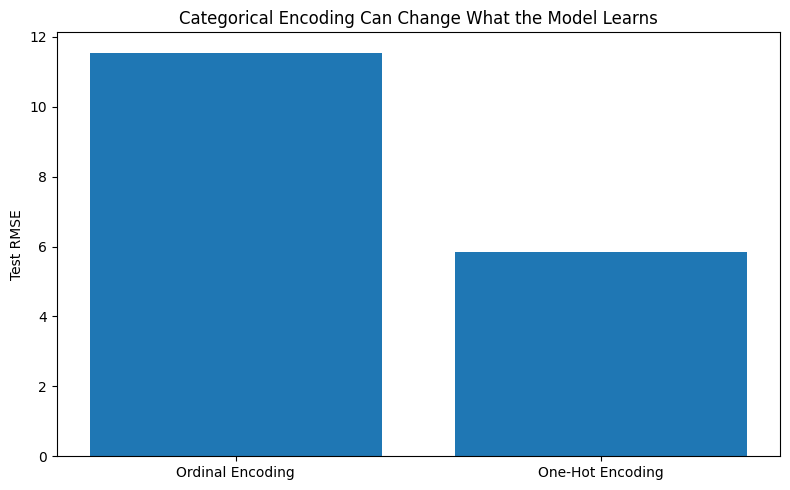

In [6]:
results = pd.DataFrame({
    'Encoding': ['Ordinal Encoding', 'One-Hot Encoding'],
    'Test RMSE': [ordinal_rmse, onehot_rmse],
    'Test R2': [ordinal_r2, onehot_r2]
})

display(results.round(3))

plt.figure(figsize=(8, 5))
plt.bar(results['Encoding'], results['Test RMSE'])
plt.ylabel('Test RMSE')
plt.title('Categorical Encoding Can Change What the Model Learns')
plt.tight_layout()
plt.show()


## What does this experiment teach?

- ML models need numerical representations, but **numbers can imply meaning**.
- Use ordinal encoding when categories have a real order, such as low < medium < high.
- Use one-hot encoding for unordered categories such as city, browser, or product type.
- Encoding should be part of the training Pipeline so transformations stay consistent.
- One-hot encoding can create many columns when a feature has many categories.

> The goal is not just to convert text into numbers. It is to convert categories into numbers **without changing their meaning**.


## References

- https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html
- https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html
- https://scikit-learn.org/stable/modules/generated/sklearn.compose.ColumnTransformer.html
- https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html
